# 영화 추천 시스템

### Movie Recommendation Work Flow

1. 라이브러리 불러오기
2. 데이터 로딩
3. 데이터 구조 확인
4. 데이터 병합
5. 평점 분포 분석
6. 영화별 평점 개수 생성 - Feature Engineering
7. 영화별 평균 평점 생성 - Feature Engineering
8. 인기 영화 추천
9. 장르 데이터 확인 - 검색 데이터, 신규회원 정보 입력
10. 장르 벡터화
11. 코사인 유사도 계산
12. 콘텐츠 기반 추천 함수 작성
13. 추천 결과 확인

###  ratings.csv
- 인기 영화 추천  : Popularity Recommendation Model
- 영화별 평점 개수, 영화별 평균 평점 => 인기 영화 추천

###  movies.csv
- 영화 장르 추천  : Content-Based Recommendation Model, Collaborative Recommendation Model
- 영화 장르 확인 및 변환(벡터화, One-Hot Encoding)
  => 코사인 유사도(영화별 평점 개수, 영화별 평균 평점 사용)
  => 유사 영화 추천  

## 1. 라이브러리 불러오기

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. 데이터 로딩

In [35]:
ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

print(ratings.head())
print(movies.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 3. 데이터 구조 확인

In [36]:
# 1. ratings, movies 구조 확인
print(ratings.shape)
print(movies.shape)

(100836, 4)
(10329, 3)


In [37]:
# 2. 컬럼 확인
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['movieId', 'title', 'genres'], dtype='object')


## 4. 결측치 & 중복 확인

In [38]:
# 결측치 확인
print(ratings.isnull().sum())
print(movies.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


In [39]:
# 중복 확인
print(ratings.duplicated().sum())
print(movies.duplicated().sum())

0
0


In [40]:
# 동일한 사용자가 동일한 영화에 중복해서 평점을 주었는지 확인
print(ratings.duplicated(subset=["userId", "movieId"]).sum())

0


## 5. ratings + movies 병합

In [41]:
movie_ratings = movies.merge(ratings, on="movieId", how="left")
print(movie_ratings.head())

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   userId  rating     timestamp  
0     1.0     4.0  9.649827e+08  
1     5.0     4.0  8.474350e+08  
2     7.0     4.5  1.106636e+09  
3    15.0     2.5  1.510578e+09  
4    17.0     4.5  1.305696e+09  


## 6. 전체 평점 분포

In [42]:
ratings_count = ratings["rating"].value_counts().sort_index()
print(ratings_count)

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


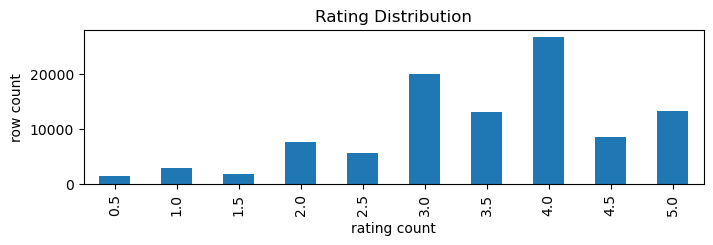

In [43]:
ratings_count.plot(kind="bar", figsize=(8,2))
plt.title("Rating Distribution")
plt.xlabel("rating count")
plt.ylabel("row count")
plt.show()

## 7. 사용자별 평점 개수

In [44]:
user_rating_count = (ratings.groupby("userId").size().reset_index(name="user_rating_count"))
print(user_rating_count)

     userId  user_rating_count
0         1                232
1         2                 29
2         3                 39
3         4                216
4         5                 44
..      ...                ...
605     606               1115
606     607                187
607     608                831
608     609                 37
609     610               1302

[610 rows x 2 columns]


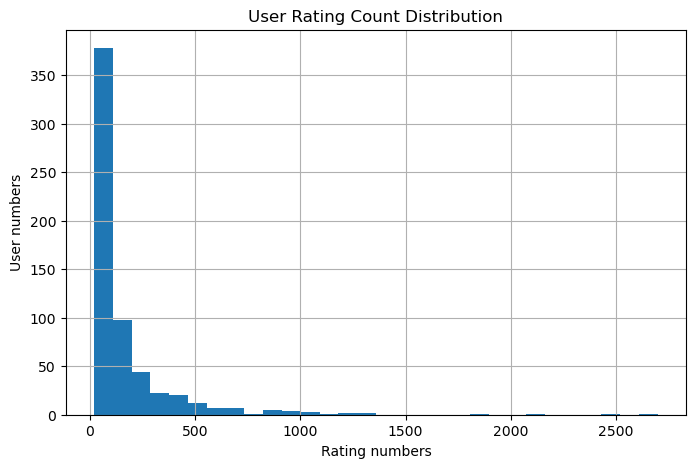

In [45]:
# 분포 확인
user_rating_count["user_rating_count"].hist(bins=30, figsize=(8,5))
plt.title("User Rating Count Distribution")
plt.xlabel("Rating numbers")
plt.ylabel("User numbers")
plt.show()

## 8. 영화별 평점 개수 Feature 생성

In [46]:
movie_rating_count = (ratings.groupby("movieId").size().reset_index(name="movie_rating_count"))
print(movie_rating_count)

      movieId  movie_rating_count
0           1                 215
1           2                 110
2           3                  52
3           4                   7
4           5                  49
...       ...                 ...
9719   193581                   1
9720   193583                   1
9721   193585                   1
9722   193587                   1
9723   193609                   1

[9724 rows x 2 columns]


In [47]:
# 영화별 평점 개수(movie_rating_count) + 영화(movies) 병합
movie_rating_count = movies.merge(movie_rating_count, on="movieId")
print(movie_rating_count)

      movieId                               title  \
0           1                    Toy Story (1995)   
1           2                      Jumanji (1995)   
2           3             Grumpier Old Men (1995)   
3           4            Waiting to Exhale (1995)   
4           5  Father of the Bride Part II (1995)   
...       ...                                 ...   
7215   144976                Bone Tomahawk (2015)   
7216   146656                        Creed (2015)   
7217   146684       Cosmic Scrat-tastrophe (2015)   
7218   148238      A Very Murray Christmas (2015)   
7219   148626                The Big Short (2015)   

                                           genres  movie_rating_count  
0     Adventure|Animation|Children|Comedy|Fantasy                 215  
1                      Adventure|Children|Fantasy                 110  
2                                  Comedy|Romance                  52  
3                            Comedy|Drama|Romance                   7  
4  

In [48]:
# 평점 개수를 기준으로 인기 영화 추천
popular_movies = movie_rating_count.sort_values("movie_rating_count", ascending=False)
print(popular_movies.head(10))

      movieId                                      title  \
300       356                        Forrest Gump (1994)   
263       318           Shawshank Redemption, The (1994)   
245       296                        Pulp Fiction (1994)   
490       593           Silence of the Lambs, The (1991)   
1846     2571                         Matrix, The (1999)   
216       260  Star Wars: Episode IV - A New Hope (1977)   
401       480                       Jurassic Park (1993)   
93        110                          Braveheart (1995)   
487       589          Terminator 2: Judgment Day (1991)   
443       527                    Schindler's List (1993)   

                                genres  movie_rating_count  
300           Comedy|Drama|Romance|War                 329  
263                        Crime|Drama                 317  
245        Comedy|Crime|Drama|Thriller                 307  
490              Crime|Horror|Thriller                 279  
1846            Action|Sci-Fi|Thri

## 9. 영화별 평균 평점 Feature 생성

In [49]:
movie_rating_mean = (ratings.groupby("movieId")["rating"].mean().reset_index(name="movie_rating_mean"))
print(movie_rating_mean)

      movieId  movie_rating_mean
0           1           3.920930
1           2           3.431818
2           3           3.259615
3           4           2.357143
4           5           3.071429
...       ...                ...
9719   193581           4.000000
9720   193583           3.500000
9721   193585           3.500000
9722   193587           3.500000
9723   193609           4.000000

[9724 rows x 2 columns]


In [50]:
# movie_stats = 평점 개수 + 평균 평점 + 영화 정보
movie_stats = movie_rating_count.merge(movie_rating_mean, on="movieId")
print(movie_stats.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  movie_rating_count  \
0  Adventure|Animation|Children|Comedy|Fantasy                 215   
1                   Adventure|Children|Fantasy                 110   
2                               Comedy|Romance                  52   
3                         Comedy|Drama|Romance                   7   
4                                       Comedy                  49   

   movie_rating_mean  
0           3.920930  
1           3.431818  
2           3.259615  
3           2.357143  
4           3.071429  


In [51]:
# 평점이 높은 영화 정렬
high_rating_movies = movie_stats.sort_values("movie_rating_mean", ascending=False)
print(high_rating_movies)

      movieId                                      title  \
1178     1631                     Assignment, The (1997)   
6415    84273           Zeitgeist: Moving Forward (2011)   
3475     5241                Seems Like Old Times (1980)   
6476    86721                   Idiots and Angels (2008)   
5453    47736                  Chump at Oxford, A (1940)   
...       ...                                        ...   
5852    60363                   Zombie Strippers! (2008)   
4648     8494                 Cincinnati Kid, The (1965)   
3142     4580                              Cyborg (1989)   
6174    72696                            Old Dogs (2009)   
6741    97024  Rust and Bone (De rouille et d'os) (2012)   

                       genres  movie_rating_count  movie_rating_mean  
1178          Action|Thriller                   1                5.0  
6415              Documentary                   1                5.0  
3475           Comedy|Romance                   1                5

In [52]:
# (1순위)평점 개수, (2순위)평균 평점이 높은 영화 정렬
high_rating_movies2 = movie_stats.sort_values(["movie_rating_count", "movie_rating_mean"], ascending=False)
print(high_rating_movies2)

      movieId                                         title  \
300       356                           Forrest Gump (1994)   
263       318              Shawshank Redemption, The (1994)   
245       296                           Pulp Fiction (1994)   
490       593              Silence of the Lambs, The (1991)   
1846     2571                            Matrix, The (1999)   
...       ...                                           ...   
6244    76030                                Case 39 (2009)   
6262    77427  Human Centipede, The (First Sequence) (2009)   
6381    82095                                Skyline (2010)   
6596    91414                       Arthur Christmas (2011)   
6741    97024     Rust and Bone (De rouille et d'os) (2012)   

                               genres  movie_rating_count  movie_rating_mean  
300          Comedy|Drama|Romance|War                 329           4.164134  
263                       Crime|Drama                 317           4.429022  
245   

In [53]:
# 기준 설정(1)
# 평가수(movie_rating_count)가 30개 이상인 영화를 기준
qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= 30]
print(qualified_movie.head(10))

    movieId                               title  \
0         1                    Toy Story (1995)   
1         2                      Jumanji (1995)   
2         3             Grumpier Old Men (1995)   
4         5  Father of the Bride Part II (1995)   
5         6                         Heat (1995)   
6         7                      Sabrina (1995)   
9        10                    GoldenEye (1995)   
10       11      American President, The (1995)   
15       16                       Casino (1995)   
16       17        Sense and Sensibility (1995)   

                                         genres  movie_rating_count  \
0   Adventure|Animation|Children|Comedy|Fantasy                 215   
1                    Adventure|Children|Fantasy                 110   
2                                Comedy|Romance                  52   
4                                        Comedy                  49   
5                         Action|Crime|Thriller                 102   
6           

In [54]:
# 기준 설정(2)
# 분위수 0.75 => 25%, 상위 25%에 해당하는 영화만 출력
# min_rating_count = movie_stats["movie_rating_count"].quantile(0.95)
# qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= min_rating_count]
# print(qualified_movie)

## 10. 인기 영화 추천 함수

In [55]:
def recommend_popular_movie(top_n):
    result = (
        qualified_movie.sort_values("movie_rating_mean", ascending=False).head(top_n)
    )

    return result[
        [
            "movieId",
            "title",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ]

In [56]:
# 인기있는 영화 Top10
recommend_popular_movie(20)

,movieId,title,movie_rating_count,movie_rating_mean
263,318,"Shawshank Redemption, The (1994)",317,4.429022
868,1204,Lawrence of Arabia (1962),45,4.300000
631,858,"Godfather, The (1972)",192,4.289062
2115,2959,Fight Club (1999),218,4.272936
937,1276,Cool Hand Luke (1967),57,4.271930
579,750,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041
657,904,Rear Window (1954),84,4.261905
884,1221,"Godfather: Part II, The (1974)",129,4.259690
5477,48516,"Departed, The (2006)",107,4.252336
876,1213,Goodfellas (1990),126,4.250000


## 11. 장르 데이터 이해

In [57]:
print(movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 12. 장르 One-Hot Encoding

In [58]:
# str.get_dummies()
genre_feature = movies["genres"].str.get_dummies(sep="|")
print(genre_feature)

       (no genres listed)  Action  Adventure  Animation  Children  Comedy  \
0                       0       0          1          1         1       1   
1                       0       0          1          0         1       0   
2                       0       0          0          0         0       1   
3                       0       0          0          0         0       1   
4                       0       0          0          0         0       1   
...                   ...     ...        ...        ...       ...     ...   
10324                   0       0          0          1         1       1   
10325                   0       0          0          0         0       1   
10326                   0       0          0          0         0       1   
10327                   0       0          0          0         0       0   
10328                   1       0          0          0         0       0   

       Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  IMAX  Musical

In [59]:
# movies에 genre_feature 컬럼 추가 - concat
movie_features = pd.concat(
    [
        movies[["movieId", "title", "genres"]],
        genre_feature
    ],
    axis=1
)
print(movie_features.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  (no genres listed)  Action  \
0  Adventure|Animation|Children|Comedy|Fantasy                   0       0   
1                   Adventure|Children|Fantasy                   0       0   
2                               Comedy|Romance                   0       0   
3                         Comedy|Drama|Romance                   0       0   
4                                       Comedy                   0       0   

   Adventure  Animation  Children  Comedy  Crime  ...  Film-Noir  Horror  \
0          1          1         1       1      0  ...          0       0   
1          1          0         1       0      0  ...          0       0   
2 

## 13. 코사인 유사도 불러오기

In [60]:
from sklearn.metrics.pairwise import cosine_similarity

In [61]:
genre_columns = genre_feature.columns
print(genre_columns)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='object')


In [62]:
# 영화간 유사도 계산하기
similarity_matrix = cosine_similarity(
    movie_features[genre_columns]
)
print(similarity_matrix.shape)
print(similarity_matrix)

(10329, 10329)
[[1.         0.77459667 0.31622777 ... 0.4472136  0.         0.        ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.70710678 0.         0.        ]
 ...
 [0.4472136  0.         0.70710678 ... 1.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.        ]]


In [63]:
similary_df = pd.DataFrame(
    similarity_matrix,
    index=movie_features["title"],
    columns=movie_features["title"]
)
similary_df
similary_df.iloc[:5, :5]

title,Toy Story (1995),Jumanji (1995),Grumpier Old Men (1995),Waiting to Exhale (1995),Father of the Bride Part II (1995)
title,,,,,
Toy Story (1995),1.000000,0.774597,0.316228,0.258199,0.447214
Jumanji (1995),0.774597,1.000000,0.000000,0.000000,0.000000
Grumpier Old Men (1995),0.316228,0.000000,1.000000,0.816497,0.707107
Waiting to Exhale (1995),0.258199,0.000000,0.816497,1.000000,0.577350
Father of the Bride Part II (1995),0.447214,0.000000,0.707107,0.577350,1.000000


## 14. 특정 영화 검색

In [64]:
# 1. 정확한 영화 제목 검색
movies[
    movies["title"].str.contains(
        "Toy Story",
        case = False,
        na = False
    )
]

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2496,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
8599,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX


In [65]:
# 2. 데이터프레임에서 검색한 영화의 인덱스 찾기
movie_index = movies[
    movies["title"] == "Toy Story (1995)"
].index[0]
print(movie_index)

0


In [66]:
# 3. 검색한 영화와 비슷한 모든 유사도를 가진 영화를 가져옴
similarity_scores = list(
    enumerate(similarity_matrix[movie_index])
)
print(similarity_scores)

[(0, np.float64(0.9999999999999999)), (1, np.float64(0.7745966692414835)), (2, np.float64(0.3162277660168379)), (3, np.float64(0.25819888974716115)), (4, np.float64(0.4472135954999579)), (5, np.float64(0.0)), (6, np.float64(0.3162277660168379)), (7, np.float64(0.6324555320336758)), (8, np.float64(0.0)), (9, np.float64(0.25819888974716115)), (10, np.float64(0.25819888974716115)), (11, np.float64(0.3162277660168379)), (12, np.float64(0.7745966692414835)), (13, np.float64(0.0)), (14, np.float64(0.25819888974716115)), (15, np.float64(0.0)), (16, np.float64(0.0)), (17, np.float64(0.4472135954999579)), (18, np.float64(0.4472135954999579)), (19, np.float64(0.19999999999999998)), (20, np.float64(0.25819888974716115)), (21, np.float64(0.0)), (22, np.float64(0.0)), (23, np.float64(0.0)), (24, np.float64(0.0)), (25, np.float64(0.0)), (26, np.float64(0.3162277660168379)), (27, np.float64(0.0)), (28, np.float64(0.39999999999999997)), (29, np.float64(0.0)), (30, np.float64(0.0)), (31, np.float64(0.0

In [67]:
# 4. 상위 영화 기준으로 정렬
similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

In [68]:
# 5. 상위 10개 추출 - 💥 첫 번째는 자기 자신이므로 제외
scores = similarity_scores[1:11]
print(scores)

[(1815, np.float64(0.9999999999999999)), (2496, np.float64(0.9999999999999999)), (2967, np.float64(0.9999999999999999)), (3166, np.float64(0.9999999999999999)), (3811, np.float64(0.9999999999999999)), (6617, np.float64(0.9999999999999999)), (6997, np.float64(0.9999999999999999)), (7382, np.float64(0.9999999999999999)), (7987, np.float64(0.9999999999999999)), (9215, np.float64(0.9999999999999999))]


In [69]:
# 6. 추천 영화 인덱스 추출
recommend_indexes = [
    index for index, score in scores
]
movies.iloc[recommend_indexes]

,movieId,title,genres
1815,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2496,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2967,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3166,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3811,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6617,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure|Animation|Children|Comedy|Fantasy
6997,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
7382,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
7987,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
9215,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy


## 14. 컨텐츠 기반 추천 함수

In [70]:
def recommend_similar_movies(title, top_n):
    matched_movies = movies[
        movies["title"].str.lower() == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame({"message": ["영화를 찾을 수 없습니다."]}) 

    movie_index = matched_movies.index[0]

    # 3. 검색한 영화와 비슷한 모든 유사도를 가진 영화를 가져옴
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    # 4. 상위 영화 기준으로 정렬
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 5. 상위 10개 출력 - 자신은 제외
    similarity_scores = similarity_scores[1:top_n+1]

    # 6. 추천 영화 인덱스 추출
    recommend_indexes = [
        index for index, score in similarity_scores
    ]

    # 7. 추천 영화 컨텐츠 가져오기
    recommendations = movies.iloc[
        recommend_indexes
    ][
        [ "movieId", "title", "genres" ]
    ].copy()

    recommendations["similarity_score"] = [
        score for index, score in similarity_scores
    ]

    return recommendations

In [71]:
recommend_similar_movies(
    "Toy Story (1995)",
    10
)

,movieId,title,genres,similarity_score
1815,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
2496,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2967,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3166,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3811,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6617,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure|Animation|Children|Comedy|Fantasy,1.0
6997,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.0
7382,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0
7987,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
9215,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.0


## 15. 컨텐츠 기반 함수 추천 결과 + 협업 필터링 추가(아이템 기반)

In [72]:
movie_result_data = movies.merge(
    movie_stats[
        [
            "movieId",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ],
    on="movieId",
    how="left"
)

print(movie_result_data.head())
print(movie_result_data.shape)

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  movie_rating_count  \
0  Adventure|Animation|Children|Comedy|Fantasy               215.0   
1                   Adventure|Children|Fantasy               110.0   
2                               Comedy|Romance                52.0   
3                         Comedy|Drama|Romance                 7.0   
4                                       Comedy                49.0   

   movie_rating_mean  
0           3.920930  
1           3.431818  
2           3.259615  
3           2.357143  
4           3.071429  
(10329, 5)


In [73]:
# 🔥 추천 함수에서 movie_result_data를 사용하도록 수정!!
def recommend_similar_movies(title, top_n=10):
    matched_movies = movies[
        movies["title"].str.lower()
        == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame(
            {"message": ["영화를 찾을 수 없습니다."]}
        )

    movie_index = matched_movies.index[0]

    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 🔥 수정 시작
    similarity_scores = similarity_scores[1:]

    results = []

    for index, score in similarity_scores:
        movie = movie_result_data.iloc[index]

        if movie["movie_rating_count"] >= 10:
            results.append({
                "movieId": movie["movieId"],
                "title": movie["title"],
                "genres": movie["genres"],
                "similarity_score": round(score, 3),
                "rating_count": int(
                    movie["movie_rating_count"]
                ),
                "rating_mean": round(
                    movie["movie_rating_mean"],
                    2
                )
            })

        if len(results) == top_n:
            break
    # 🔥 수정 종료

    return pd.DataFrame(results)

In [74]:
recommend_similar_movies(
    "Toy Story (1995)",
    10
)

,movieId,title,genres,similarity_score,rating_count,rating_mean
0,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.000,45,3.24
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.000,97,3.86
2,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.000,37,3.72
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.000,132,3.87
4,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.000,21,3.02
5,673,Space Jam (1996),Adventure|Animation|Children|Comedy|Fantasy|Sc...,0.913,53,2.71
6,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.913,170,3.87
7,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.913,55,4.11
8,108932,The Lego Movie (2014),Action|Adventure|Animation|Children|Comedy|Fan...,0.913,31,3.87
9,1848,"Borrowers, The (1997)",Adventure|Children|Comedy|Fantasy,0.894,12,3.04
